<a href="https://colab.research.google.com/github/mcnica89/DATA6100/blob/main/lab_06_6_ridge_regression_and_lasso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Heavily borrows from http://www.science.smith.edu/~jcrouser/SDS293/labs/

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
# imports and setup
%matplotlib inline

from sklearn.linear_model import Ridge, RidgeCV, Lasso, LassoCV, LinearRegression

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('precision', 4) # number precision for pandas
pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', 12)
pd.set_option('display.float_format', '{:20,.5f}'.format) # get rid of scientific notation

plt.style.use('seaborn') # pretty matplotlib plots

In [26]:
hitters = pd.read_csv('https://raw.githubusercontent.com/mcnica89/ISL-python/master/datasets/Hitters.csv', index_col=0).dropna()
hitters.index.name = 'Player'

hitters = hitters.iloc[:, [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,18]] # push salary at the end

hitters['League'] = pd.get_dummies(hitters['League']).iloc[:, 1]
hitters['Division'] = pd.get_dummies(hitters['Division']).iloc[:, 1]
hitters['NewLeague'] = pd.get_dummies(hitters['NewLeague']).iloc[:, 1]

normalized_hitters=(hitters-hitters.mean())/hitters.std()


In [27]:
hitters.head

<bound method NDFrame.head of                    AtBat  Hits  HmRun  Runs  RBI  Walks  ...  Division  \
Player                                                   ...             
-Alan Ashby          315    81      7    24   38     39  ...         1   
-Alvin Davis         479   130     18    66   72     76  ...         1   
-Andre Dawson        496   141     20    65   78     37  ...         0   
-Andres Galarraga    321    87     10    39   42     30  ...         0   
-Alfredo Griffin     594   169      4    74   51     35  ...         1   
...                  ...   ...    ...   ...  ...    ...  ...       ...   
-Willie McGee        497   127      7    65   48     37  ...         0   
-Willie Randolph     492   136      5    76   50     94  ...         0   
-Wayne Tolleson      475   126      3    61   43     52  ...         1   
-Willie Upshaw       573   144      9    85   60     78  ...         0   
-Willie Wilson       631   170      9    77   44     31  ...         1   

       

# Ordinarly Least Squares 

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


X = hitters.iloc[:, 0:19]
y = hitters.iloc[:, 19]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [38]:
# "good" ridge model
ols_model = LinearRegression(normalize=True)
ols_fit = ols_model.fit(X_train, y_train)
y_pred = ols_model.predict(X_test)

print(pd.Series(ols_fit.coef_, index=X.columns))
print('MSE:', mean_squared_error(y_test, y_pred))

AtBat                   -0.61277
Hits                     0.65915
HmRun                    0.00494
Runs                    -0.02524
RBI                      0.00223
Walks                    0.21967
Years                    0.06531
CAtBat                  -1.80633
CHits                    1.42204
CHmRun                   0.28977
CRuns                    0.56223
CRBI                     0.19166
CWalks                  -0.26074
League                   0.05760
Division                -0.12943
PutOuts                  0.17818
Assists                  0.04585
Errors                   0.02424
NewLeague               -0.00361
dtype: float64
MSE: 0.6564606353993145


# Ridge Regression Code



In [ ]:
from sklearn.preprocessing import scale

def plot_ridge_regression(X,y):

  grid = 10 ** np.linspace(3,-2,100)

  ridge_model = Ridge(normalize=True)
  coefs = []

  for a in grid:
      ridge_model.set_params(alpha=a)
      ridge_model.fit(X, y)
      coefs.append(ridge_model.coef_)

  ax = plt.gca()
  ax.plot(grid, coefs)
  ax.set_xscale('log')
  ax.legend(X.columns)

  plt.title("Coefficients vs Regularization Parameter (Normalized)")
  plt.axis('tight')
  plt.xlabel('ridge regularization parameter')
  plt.ylabel('weights');

# 6.6.1 Ridge Regression (UN-Normalized!)

## How do the coeffiencts change as a function of the regularization param?

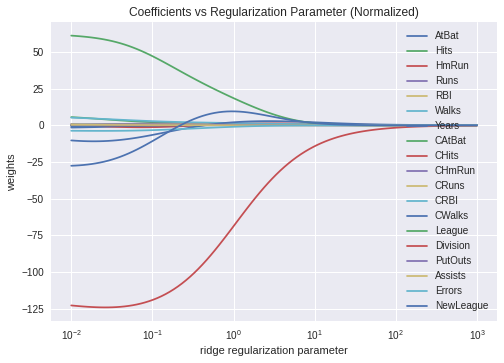

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


X = hitters.iloc[:, 0:19]
y = hitters.iloc[:, 19]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

plot_ridge_regression(X,y)

# 6.6.1 Ridge Regression (Normalized!)

## How do the coeffiencts change as a function of the regularization param?

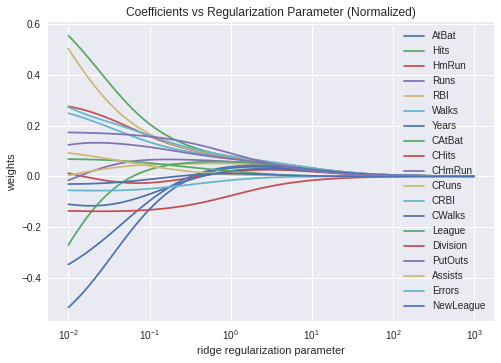

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


X = normalized_hitters.iloc[:, 0:19]
y = normalized_hitters.iloc[:, 19]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

plot_ridge_regression(X,y)

# Using Validation to find the "best" regularization parameter

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=1)

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=1)

grid = 10 ** np.linspace(1,-2,100)

ridge_model = Ridge(normalize=True)
coefs = []
test_MSE = []


for a in grid:
    ridge_model.set_params(alpha=a)
    ridge_model.fit(X_train, y_train)
    coefs.append(ridge_model.coef_)

    preds = ridge_model.predict(X_test)

    test_MSE.append( np.mean( (preds - y_test)**2 ) )

Best regularization value found:  0.9326033468832199


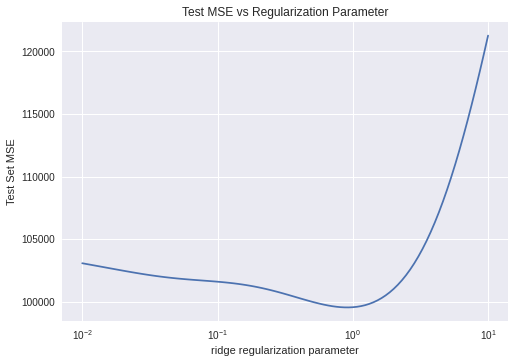

In [12]:
ax = plt.gca()
ax.plot(grid, test_MSE)
ax.set_xscale('log')
plt.title("Test MSE vs Regularization Parameter")
plt.axis('tight')
plt.xlabel('ridge regularization parameter')
plt.ylabel('Test Set MSE');

print("Best regularization value found: ", grid[np.argmin(test_MSE)]  )

# Trying different ridge params

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=1)

In [14]:
# "good" ridge model
ridge2 = Ridge(alpha=1.0, normalize=True)
ridge2_fit = ridge2.fit(X_train, y_train)
y_pred2 = ridge2.predict(X_test)

print(pd.Series(ridge2_fit.coef_, index=X.columns))
print('MSE:', mean_squared_error(y_test, y_pred2))

AtBat                    0.05555
Hits                     0.71027
HmRun                    0.62125
Runs                     0.77330
RBI                      1.18455
Walks                    1.74892
Years                    2.21549
CAtBat                   0.00851
CHits                    0.04744
CHmRun                   0.43015
CRuns                    0.09769
CRBI                     0.10897
CWalks                   0.10404
League                  14.22294
Division               -74.09002
PutOuts                  0.22633
Assists                 -0.01598
Errors                   0.02312
NewLeague               10.24613
dtype: float64
MSE: 99554.04893196118


In [15]:
# very high lambda
ridge3 = Ridge(alpha=1e10, normalize=True)
ridge3_fit = ridge3.fit(X_train, y_train)
y_pred3 = ridge3.predict(X_test)

print(pd.Series(ridge3_fit.coef_, index=X.columns))
print('MSE:', mean_squared_error(y_test, y_pred3))

AtBat                    0.00000
Hits                     0.00000
HmRun                    0.00000
Runs                     0.00000
RBI                      0.00000
Walks                    0.00000
Years                    0.00000
CAtBat                   0.00000
CHits                    0.00000
CHmRun                   0.00000
CRuns                    0.00000
CRBI                     0.00000
CWalks                   0.00000
League                  -0.00000
Division                -0.00000
PutOuts                  0.00000
Assists                 -0.00000
Errors                   0.00000
NewLeague               -0.00000
dtype: float64
MSE: 172862.23580379886


In [16]:
# lambda=0 -> OLS
ridge4 = Ridge(alpha=0, normalize=True)
ridge4_fit = ridge4.fit(X_train, y_train)
y_pred4 = ridge4.predict(X_test)

print(pd.Series(ridge4_fit.coef_, index=X.columns))
print('MSE:', mean_squared_error(y_test, y_pred4))

AtBat                   -1.82111
Hits                     4.25916
HmRun                   -4.77340
Runs                    -0.03876
RBI                      3.98458
Walks                    3.47013
Years                    9.49824
CAtBat                  -0.60513
CHits                    2.17498
CHmRun                   2.97931
CRuns                    0.26636
CRBI                    -0.59846
CWalks                   0.17138
League                 133.74316
Division              -113.74387
PutOuts                  0.42106
Assists                  0.46438
Errors                  -6.02458
NewLeague              -81.92776
dtype: float64
MSE: 116690.46856660531


# Automatically choosing the best parameter

In [17]:
# cross validated ridge (10-fold)
# Automatically do 10 fold cross validation to choose the best ridge parameter
ridge_cv = RidgeCV(alphas=grid, normalize=True, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train, y_train)
print("Best regularization param value found: ", ridge_cv.alpha_)

Best regularization param value found:  0.5722367659350217


In [18]:
# cv_lambda
ridge5 = Ridge(alpha=ridge_cv.alpha_, normalize=True)
ridge5_fit = ridge5.fit(X_train, y_train)
y_pred5 = ridge5.predict(X_test)

print(pd.Series(ridge5_fit.coef_, index=X.columns))
print('Ridge Value: ',ridge_cv.alpha_)
print('MSE:', mean_squared_error(y_test, y_pred5))

AtBat                   -0.01428
Hits                     0.86572
HmRun                   -0.30056
Runs                     0.72139
RBI                      1.31946
Walks                    2.09588
Years                    1.18962
CAtBat                   0.00663
CHits                    0.05206
CHmRun                   0.51382
CRuns                    0.10683
CRBI                     0.12847
CWalks                   0.09886
League                  18.95769
Division               -92.31369
PutOuts                  0.28068
Assists                 -0.01722
Errors                  -0.31915
NewLeague                9.92201
dtype: float64
Ridge Value:  0.5722367659350217
MSE: 99830.73600177479


# The Lasso

In [46]:
from sklearn.preprocessing import scale

def plot_lasso_regression(X,y,grid = None):
  if grid is None:
    grid = 10 ** np.linspace(3,-2,100)

  lasso_model = Lasso(normalize=True, max_iter=10000) # max_iter=10000 for removing ConvergenceWarning
  coefs = []

  for a in grid:
      lasso_model.set_params(alpha=a)
      lasso_model.fit(scale(X_train), y_train)
      coefs.append(lasso_model.coef_)

  ax = plt.gca()
  ax.plot(grid, coefs)
  ax.set_xscale('log')
  ax.legend(X.columns)

  plt.axis('tight')
  plt.xlabel('alpha')
  plt.title("Coeff Values vs Lasso Parameter")
  plt.ylabel('weights');

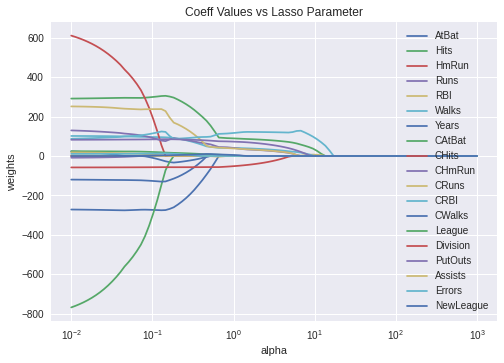

In [47]:
X = hitters.iloc[:, 0:19]
y = hitters.iloc[:, 19]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

plot_lasso_regression(X,y)

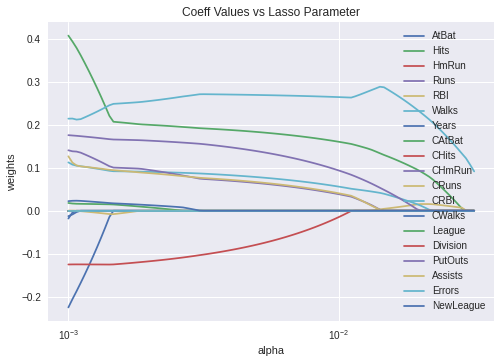

In [51]:
X = normalized_hitters.iloc[:, 0:19]
y = normalized_hitters.iloc[:, 19]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

plot_lasso_regression(X,y,  grid = 10 ** np.linspace(-1.5,-3,100))

In [52]:
lasso_cv = LassoCV(alphas=grid, max_iter=100000, normalize=True, cv=10)
lasso_cv.fit(X_train, y_train)
lasso_cv.alpha_

0.01

In [53]:
lasso2 = Lasso(alpha=lasso_cv.alpha_, normalize=True, max_iter=10000)
lasso2_fit = lasso2.fit(X_train, y_train)
y_pred2 = lasso2_fit.predict(X_test)

print(pd.Series(lasso2_fit.coef_, index=X.columns))
print('MSE:', mean_squared_error(y_test, y_pred2))

AtBat                    0.00000
Hits                     0.16357
HmRun                    0.00000
Runs                     0.00000
RBI                      0.00000
Walks                    0.05405
Years                    0.00000
CAtBat                   0.00000
CHits                    0.00000
CHmRun                   0.03820
CRuns                    0.03981
CRBI                     0.25901
CWalks                   0.00000
League                   0.00000
Division                -0.01465
PutOuts                  0.09164
Assists                 -0.00000
Errors                   0.00000
NewLeague                0.00000
dtype: float64
MSE: 0.7182421040468159
